# Run Route Optimization

## Install Libraries

Run the cell below or you can create a virtual environment using requirements.txt

In [1]:
!pip install pandas numpy matplotlib seaborn tqdm torch torchvision torchaudio torch-geometric kloppy requests

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

from src2.get_data import collect_data_from_matches

from src2.model_building import TemporalRunnerDataset, train_model, collate_fn, predict_optimal_run, evaluate_all_runs, build_graph_from_frame, TemporalRunnerDataset, TemporalRunnerGNN


from src2.visualization_tools import plot_soccer_pitch, animate_run, plot_spatial_graph,plot_optimal_runs

# Load Data

Here we load the data from the Skill Corner Open Source Dataset. We only load one game so it doesn't take too long. However, when training the model data from all 10 games was used.

In [ ]:
matches = [1886347]
possessions, run_features, tracking_data, player_to_team, merged = collect_data_from_matches(matches)

In [4]:
merged["event_subtype"].dropna().unique()

array(['pulling_wide', 'coming_short', 'behind', 'support', 'overlap',
       'cross_receiver', 'dropping_off', 'run_ahead_of_the_ball',
       'pulling_half_space', 'underlap'], dtype=object)

# Filtering by Cross Receiver, Behind, Overlap, Support, and Coming Short Runs for Route Prediction

In [5]:
run_types_to_predict = merged["event_subtype"].dropna().unique()

In [6]:
# run_types_to_predict = ['cross_receiver','behind',"overlap","support","coming_short"]
run_type_to_int = {run_type: idx for idx, run_type in enumerate(run_types_to_predict)}
runs_to_predict = merged[merged.event_subtype.isin(run_types_to_predict)]

# Grouping tracking data by Match ID and Run ID for performance benefits

In [7]:
tracking_frame_groups = {
    (mid, rid): df
    for (mid, rid), df in tracking_data.groupby(
        ["match_id", "run_id"]
    )
}

# Validating that we can build graphs for each run

Here we are ensuring that we can build a series of graphs for each run

In [8]:
def validate_run(run_row):
    runner_id = run_row["player_id"]
    match_id = run_row["match_id"]
    run_id = run_row["event_id"]

    frame_start = int(run_row["frame_start_run"])
    frame_end = int(run_row["frame_end_run"])

    tracking = tracking_frame_groups[(match_id, run_id)]

    lower_frame = max(frame_start-10,tracking["frame_id"].min())
    
    expected_frames = set(range(lower_frame, frame_end + 1))
    actual_frames = set(tracking["frame_id"].unique().tolist())

    if not expected_frames.issubset(actual_frames):
        return False
    
    runner_per_frame = (
        tracking
        .groupby("frame_id")["player"]
        .apply(lambda players: runner_id in players.values)
    )
    return runner_per_frame.all()
runs_to_predict = runs_to_predict[runs_to_predict.apply(validate_run,axis=1)]

In [9]:
runs_to_predict.columns

Index(['possession_index', 'match_id', 'period_possession',
       'phases_indexes_possession', 'frame_start_possession',
       'frame_end_possession', 'team_id_possession', 'phase_types',
       'possession_lead_to_shot', 'possession_lead_to_goal',
       'possession_leads_to_box', 'event_id', 'frame_start_run',
       'frame_end_run', 'time_start', 'time_end', 'minute_start',
       'second_start', 'duration', 'period_run', 'event_subtype', 'player_id',
       'player_name', 'player_position', 'team_id', 'team_shortname',
       'x_start', 'y_start', 'x_end', 'y_end', 'game_state', 'team_score',
       'opponent_team_score', 'phase_index', 'team_in_possession_phase_type',
       'team_out_of_possession_phase_type', 'lead_to_shot', 'lead_to_goal',
       'distance_covered', 'trajectory_angle', 'trajectory_direction',
       'separation_start', 'separation_end', 'separation_gain',
       'last_defensive_line_x_start', 'last_defensive_line_x_end',
       'delta_to_last_defensive_line_s

# Splitting our training and test sets

In [10]:
runs_to_predict_test = runs_to_predict.sample(frac=.2, replace = False, random_state = 42)

runs_to_predict_train = runs_to_predict.drop(runs_to_predict_test.index)

# Build Graph

Here we build a graph representation for one frame of tracking data:

- **Nodes:** Each player and the ball are represented as nodes.
- **Node Features:**  
  - Player nodes include spatial features (`x`, `y`), velocity (`dx`, `dy`), speed, direction, acceleration, and acceleration direction.  
  - The ball node includes its position, velocity, speed, and acceleration features.
- **Additional Node Flags:**  
  - A binary flag marks the runner player (the player of interest).  
  - Another flag distinguishes the ball node.
- **Edges:** Fully connected between all nodes except self-loops.
- **Edge Attributes:** Include relative distance, whether connected nodes are on the same team, if either node is the ball, and relative speed projected along the direction between nodes.
- **Runner Index:** Stores the position of the runner player node within the node list for easy extraction.

This rich spatial and relational graph captures both player and ball states and their interactions at a single time frame, suitable for our temporal graph neural network.

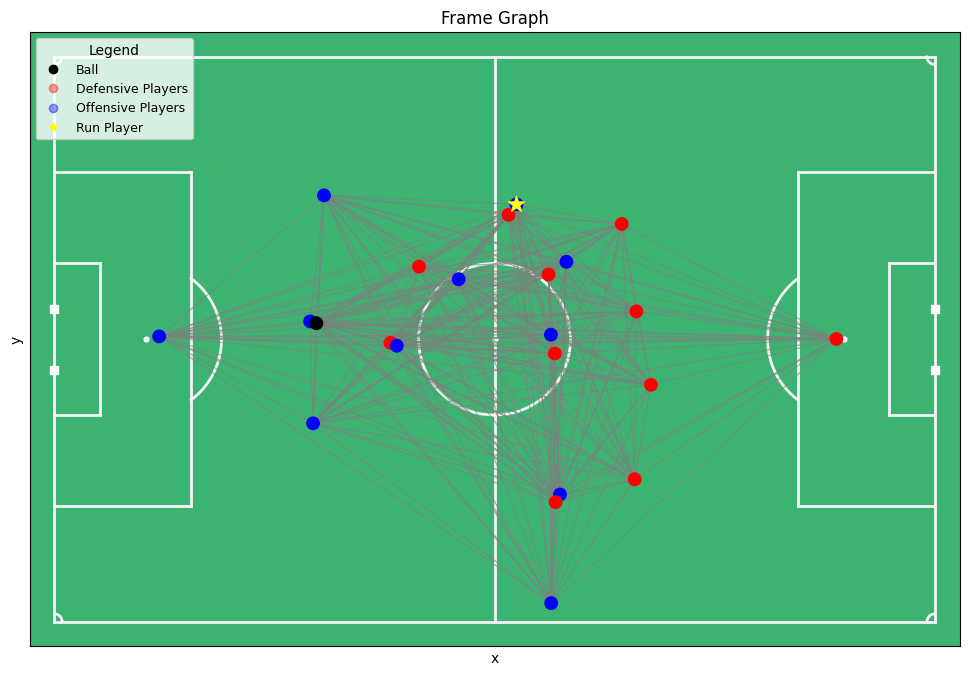

In [11]:
RUN_NUM = 0

RUN_FRAME = 1
run = runs_to_predict.iloc[RUN_NUM]
match_id = run["match_id"]
run_id = run["id"]
player = run["player_id"]

run_tracking = tracking_data[(tracking_data.run_id == run_id) & (tracking_data.match_id == match_id)]
run_tracking["timestamp"] = pd.to_timedelta(run_tracking["timestamp"]).dt.total_seconds()
frame_num = run_tracking["frame_id"].sort_values().iloc[0] + RUN_FRAME
frame_df = run_tracking[run_tracking["frame_id"]==frame_num]


graph = build_graph_from_frame(frame_df=frame_df,runner_player_id=player,player_to_team=player_to_team)
%matplotlib inline
plot_spatial_graph(graph)

# Temporal Dataset class
This dataset prepares inputs for the trajectory prediction model by:

- Extracting sequences of frames for each run, represented as graphs.
- Computing player-relative positions as target trajectories.
- Providing binary labels indicating whether the run possession led to a shot or goal.

Each sample returns:
- A list of graphs (one per frame),
- The target trajectory as a tensor of relative (x, y) positions,
- Shot and goal binary labels.

This structure enables training models to learn spatial-temporal player movements and link them to key possession outcomes.

In [12]:
dataset = TemporalRunnerDataset(
    tracking_df=tracking_frame_groups,
    run_features=runs_to_predict_train,
    player_to_team=player_to_team,
    run_type_to_int=run_type_to_int
)

# Temporal GNN

This model predicts player trajectories by combining spatial graph neural networks and temporal Transformers.

- **Input:** Batch of graphs representing player positions and interactions per frame.
- **Spatial Encoding:** Two TransformerConv layers extract spatial features from graph nodes and edges.
- **Temporal Encoding:** Extracted runner embeddings per frame are processed by a Transformer encoder with learned positional encoding and causal masking to model sequential dependencies.
- **Output:** Predicted 2D trajectory coordinates for each timestep in the run.

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

node_feat_dim = 10
edge_dim = 4
gnn_hidden_dim = 64  
num_run_types = len(run_types_to_predict) 

model = TemporalRunnerGNN(node_feat_dim,edge_dim,gnn_hidden_dim,num_run_types).to(device)

# Training Loop

The cell below will train the model on the data and save the model to the output file. We do not need to run this cell as it takes a while to train the model and I have already done it for us.

In [14]:
# from torch.utils.data import DataLoader
# dataloader = DataLoader(
#     dataset,
#     batch_size=4,
#     shuffle=True,
#     collate_fn=collate_fn
# )

# model = train_model(model,device = device, dataloader=dataloader,num_epochs=40,output_file="temporal_runner_gnn_traj_intent_gnn.pth")


# Since model is already trained we will load it below

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

node_feat_dim = 10
edge_dim = 4
gnn_hidden_dim = 64   

model = TemporalRunnerGNN(node_feat_dim,edge_dim,gnn_hidden_dim,num_run_types=num_run_types).to(device)
model.load_state_dict(torch.load("temporal_runner_gnn_traj_intent_gnn.pth",map_location=torch.device('cpu')))
model.to(device)
model.eval() 

TemporalRunnerGNN(
  (gnn1): TransformerConv(74, 64, heads=4)
  (gnn2): TransformerConv(64, 64, heads=4)
  (att_mlp): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (global_attention): GlobalAttention(gate_nn=Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  ), nn=None)
  (run_type_embed): Embedding(10, 64)
  (start_pos_mlp): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (intent_proj): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (temporal_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttent

# View the optimized runs from our TemporalGNN Below

In [16]:
['pulling_wide', 'coming_short', 'behind', 'support', 'overlap',
       'cross_receiver', 'dropping_off', 'run_ahead_of_the_ball',
       'pulling_half_space', 'underlap']

runs_to_visualize = runs_to_predict[runs_to_predict.event_subtype=="overlap"]

In [50]:
#### CHANGE THIS ####
RUN_NUM = 10

In [51]:
model.eval()
run = runs_to_visualize.iloc[RUN_NUM]
match_id = run['match_id']
run_id = run['event_id']
runner_id = run['player_id']
team_id = run["team_id"]

actual_run_type = run["event_subtype"]
run_types_to_predict_route = ["support","overlap","underlap","behind"]
paths = {}

for run_type in run_types_to_predict_route:
    absolute_path = predict_optimal_run(run,model,tracking_frame_groups=tracking_frame_groups,device = device,player_to_team = player_to_team,run_type_to_int = run_type_to_int,run_type_to_predict=run_type)
    absolute_path = absolute_path.cpu()
    paths[run_type] = absolute_path

# Plot Optimal Run Path

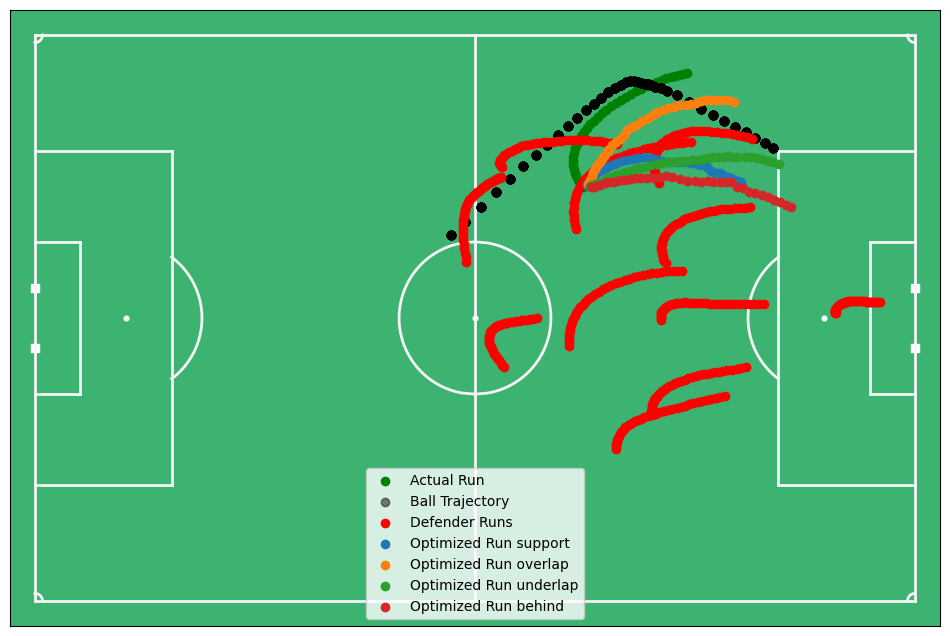

In [52]:
%matplotlib inline
plot_optimal_runs(run,tracking_frame_groups=tracking_frame_groups,player_to_team=player_to_team,absolute_paths=paths,plot_defense=True,plot_ball=True)

# View the animated tracking video sequence including the optimized run

### Quick data transformation for animation

In [20]:
# Transform for animation
run_tracking = tracking_frame_groups[(match_id, run_id)].sort_values('frame_id')
pred_x = pd.Series(absolute_path[:,0])
pred_y = pd.Series(absolute_path[:,1])
dx = pred_x - pred_x.shift(1)
dy = pred_y - pred_y.shift(1)
s = np.sqrt(dx**2 + dy**2) * 10
d = np.arctan2(dy,dx)
pred_vals = pd.concat([pred_x,pred_y,dx,dy,s,d],axis=1)
pred_vals.columns = ["x","y","dx","dy","s","d"]
pred_vals["player"] = -1
pred_run = run_tracking[(run_tracking.run_active) & (run_tracking.player==runner_id)].copy()
pred_run.loc[:,["x","y","dx","dy","s","d","player"]] = pred_vals.fillna(0).values

### Run the cell below to create the animation

In [21]:
%matplotlib tk

run_tracking_with_pred = pd.concat([run_tracking,pred_run])
ani = animate_run(run=run,tracking_data=run_tracking_with_pred,player_to_team=player_to_team)

In [22]:
# from matplotlib.animation import FuncAnimation, PillowWriter

# ani.save("cross_receiver.gif", writer=PillowWriter(fps=10))